# 12. Chromium and uranium

Two short cases, chosen because they are the metals bioremediation is
actually asked to deal with, and because each one shows a limit of these
diagrams that the earlier notebooks did not.

* **Chromium** has no elemental form in any database we carry, so its Frost
  diagram has no honest zero — the slopes still mean something and the
  heights do not.
* **Uranium** has one step, and that step does not move with pH at all,
  which is unusual enough to be worth explaining.

In [1]:
import warnings

import matplotlib.pyplot as plt

import microbial_thermo as mt
from microbial_thermo.figures import frost_diagram, latimer_diagram, plot_frost, plot_latimer, plot_pourbaix

warnings.filterwarnings("ignore", category=UserWarning)

## Chromium: the diagram that says what it does not know

In [2]:
ladder = latimer_diagram("Cr", pH=7.0)
ladder.to_frame()

,oxidized,reduced,n electrons,E (V),dG (kJ/mol element),half reaction
0,CrO4--,Cr+++,3.0,0.359202,-103.9731,CrO4-- + 8 H+ + 3 e- -> Cr+++ + 4 H2O
1,Cr+++,Cr++,1.0,-0.429305,41.4216,Cr+++ + e- -> Cr++


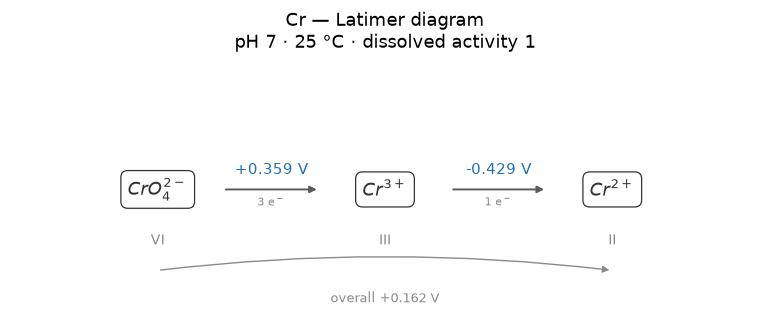

In [3]:
plot_latimer("Cr", diagram=ladder)
plt.show()

In [4]:
frost = frost_diagram("Cr", pH=7.0)
print("zero point used:", frost.reference)
print("is it a genuine elemental form?", frost.reference_is_element)

zero point used: Cr++
is it a genuine elemental form? False


`False`. Chromium metal is in none of our databases, so the reference falls
back to the first species offered — Cr²⁺ — and the y axis of the Frost
diagram becomes an arbitrary offset. The figure prints that in red rather
than quietly drawing a plausible-looking diagram:

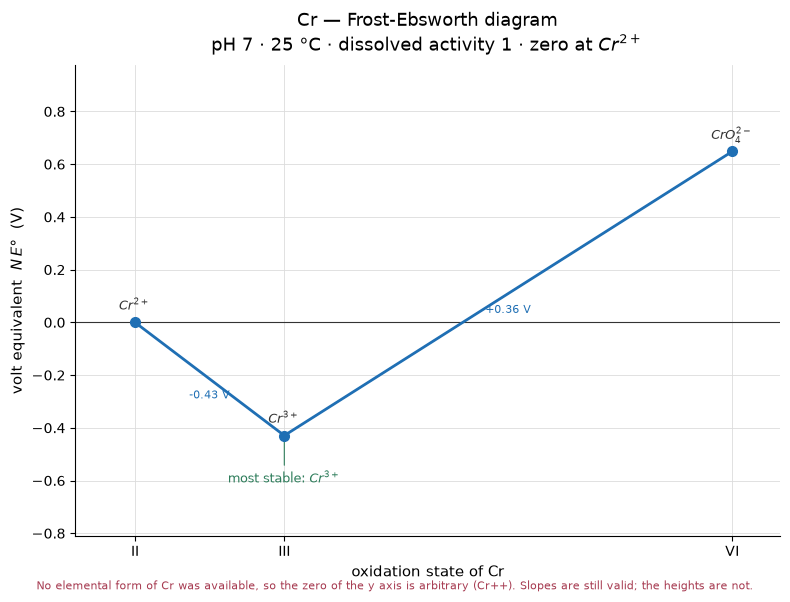

In [5]:
plot_frost("Cr", pH=7.0, annotate_slopes=True)
plt.show()

**What survives and what does not.** A volt equivalent is a height, so every
height on that figure is meaningless. A couple potential is a *difference*
of heights, so every slope is exactly right — the arbitrary offset cancels.
The Latimer diagram, which only ever shows differences, is unaffected.

This is worth internalising because it is the general rule: on an Eh–pH
diagram the element reference cancels everywhere, on a Frost diagram it sets
the zero, and on a Latimer diagram it never appears.

### The chemistry that matters

In [6]:
for ph in (2.0, 5.0, 7.0, 9.0):
    steps = latimer_diagram("Cr", pH=ph).steps
    chain = "  ".join(f"{s.oxidized.backend} –({s.potential:+.3f})→ {s.reduced.backend}" for s in steps)
    print(f"pH {ph:4.1f}   {chain}")

pH  2.0   HCrO4- –(+1.059)→ Cr+++  Cr+++ –(-0.429)→ Cr++
pH  5.0   HCrO4- –(+0.645)→ Cr+++  Cr+++ –(-0.429)→ Cr++
pH  7.0   CrO4-- –(+0.359)→ Cr+++  Cr+++ –(-0.429)→ Cr++
pH  9.0   CrO4-- –(+0.044)→ Cr+++  Cr+++ –(-0.429)→ Cr++


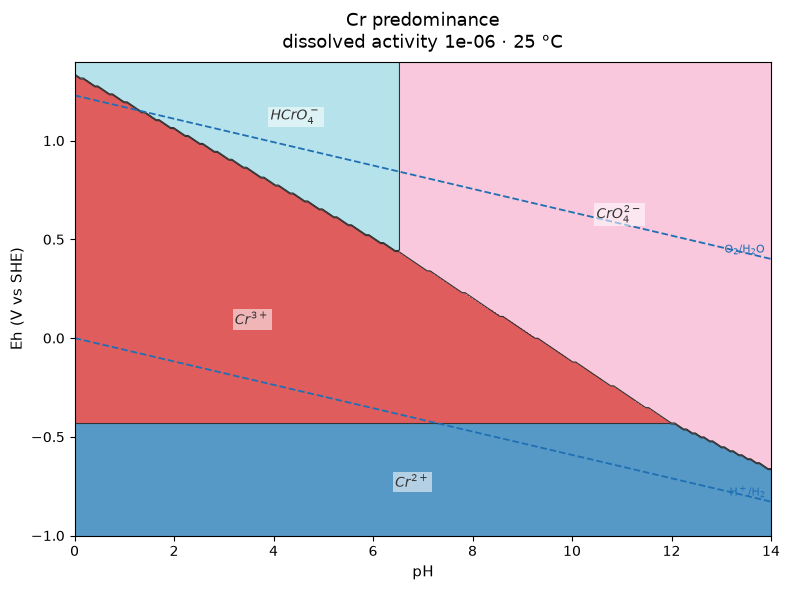

In [7]:
plot_pourbaix("Cr", figsize=(8.0, 6.0))
plt.show()

Chromate — Cr(VI) — is a strong oxidant, soluble at every pH, and the
carcinogenic form. Cr(III) is the benign one and is nearly insoluble as the
hydroxide, though our species list carries only the aqueous ion. The
remediation strategy is simply to reduce it, and the potential says that is
easy: +0.36 V at pH 7 against almost any donor a sediment has.

The pH dependence is steep, though. In acid the same couple is worth over a
volt, which is why chromate is far more aggressive in acidic waste.

## Uranium: one step, and it ignores pH

In [8]:
for ph in (2.0, 5.0, 7.0, 9.0):
    steps = latimer_diagram("U", pH=ph).steps
    chain = "  ".join(f"{s.oxidized.backend} –({s.potential:+.3f})→ {s.reduced.backend}" for s in steps)
    print(f"pH {ph:4.1f}   {chain}")

pH  2.0   UO2++ –(+0.410)→ Uraninite
pH  5.0   UO2++ –(+0.410)→ Uraninite
pH  7.0   UO2++ –(+0.410)→ Uraninite
pH  9.0   UO2++ –(+0.410)→ Uraninite


Identical at every pH, which is rare enough to be worth checking rather than
assuming. The reason is in the half reaction:

In [9]:
ladder = latimer_diagram("U", pH=7.0)
for step in ladder.steps:
    print(step.half_reaction())

UO2++ + 2 e- -> Uraninite


**No protons appear.** Uranyl carries its two oxygens into uraninite
unchanged, so there is no H⁺ term, and with no H⁺ term there is no pH
dependence — the −59 mV per proton per electron that moves every other
diagram in this series has nothing to act on.

That has a practical consequence: uranium bioremediation works over the
whole pH range of natural waters, which is not true of chromium.

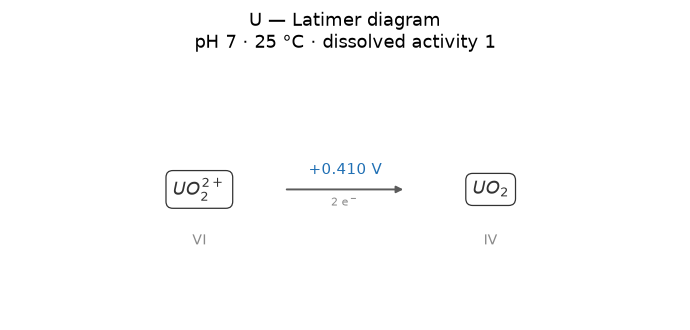

In [10]:
plot_latimer("U", diagram=ladder)
plt.show()

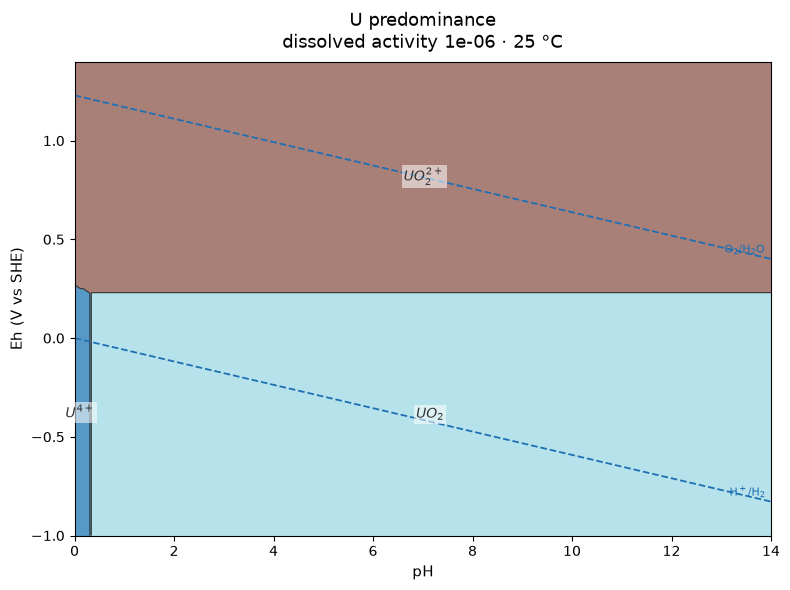

In [11]:
plot_pourbaix("U", figsize=(8.0, 6.0))
plt.show()

Uraninite — UO₂, the ore mineral — takes the entire lower half of the
diagram. Uranium is the clean case of "reduction immobilises": U(VI) is
soluble and mobile, U(IV) is a solid, and the boundary sits right in the
middle of the range a sediment can reach.

## Who lives on each step

In [12]:
conditions = mt.Conditions(temperature_c=25.0, pH=7.0)
table = mt.energy_table(conditions).set_index("name")
table.loc[
    [
        "chromate_reduction_acetate",
        "chromate_reduction_hydrogen",
        "uranium_reduction_acetate",
    ]
][["label", "dG per e- (kJ/mol)", "reaction"]]

Duplicate found for species "Fluorphlogopite" in supcrtbl.dat
Duplicate found for species "Arsenic" in supcrtbl.dat
Duplicate found for species "Arsenolite" in supcrtbl.dat


,label,dG per e- (kJ/mol),reaction
name,,,
chromate_reduction_acetate,Chromate reduction with acetate,-60.652946,1/4 Acetate + 43/12 H+ + 2/3 CrO4-- -> 1/2 CO2...
chromate_reduction_hydrogen,Chromate reduction with hydrogen,-74.613766,10/3 H+ + H2(g) + 2/3 CrO4-- -> 2/3 Cr+++ + 8/...
uranium_reduction_acetate,Uranium(VI) reduction with acetate,-65.596806,1/4 Acetate + 1/2 H2O + UO2++ -> 1/2 CO2(aq) +...


Chromate on either donor pays like a respiration, because that is what it
is: *Shewanella* and *Desulfovibrio* reduce Cr(VI) as an electron acceptor,
not as a detoxification. The engineering problem is delivery, not energy.

There is a catch that the thermodynamics cannot show, and it is worth
stating because it is where this kind of analysis stops being sufficient.
Cr(VI) crosses cell membranes on the **sulfate transporter** — chromate and
sulfate are near-identical in size and charge — so it gets inside, and once
inside, partial reduction produces Cr(V) and Cr(IV) radicals that damage
DNA. The reaction that makes chromium safe in a sediment is the same
reaction that makes it carcinogenic in a cell.

Nothing on a Frost or Eh–pH diagram will ever tell you that. They constrain
what is possible; toxicity lives in the kinetics and the transport.

## One thing worth taking away

Both of these are real bioremediation strategies and both are thermodynamic
gifts: the organisms are respiring a contaminant that happens to become
insoluble when reduced, and they would do it whether or not anyone wanted
them to. The engineering is entirely about delivering electrons.

Compare arsenic in notebook 10, where exactly the same microbial process
does exactly the wrong thing.